# Сравнение различных подходов к Voice Activity Detection (VAD)
В этом ноутбуке мы реализуем и сравним 4 подхода к детектированию речи на датасете RAVDESS:
1. **MLP** (Многослойный перцептрон) на признаках MFCC
2. **LSTM** (Рекуррентная сеть) для учета временного контекста
3. **1D-CNN** (Сверточная сеть) для извлечения паттернов из аудио
4. **MediaPipe** (Визуальный VAD) на основе расстояния между губами

In [2]:
import os
import cv2
import librosa
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
import gc

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


## 1. Подготовка данных RAVDESS

In [3]:
RAVDESS_PATH = "../datasets/ravdess/"
MODEL_ASSET_PATH = "../raw_models/face_landmarker.task"

def get_paired_files(path, limit=100):
    """Находит пары аудио-видео файлов RAVDESS"""
    pairs = []
    # Ищем в Audio_Speech
    audio_base = os.path.join(path, "Audio_Speech_Actors_01-24")
    for actor_dir in sorted(os.listdir(audio_base)):
        if not actor_dir.startswith("Actor_"): continue
        audio_path = os.path.join(audio_base, actor_dir)
        for file in os.listdir(audio_path):
            if file.endswith(".wav"):
                video_name = "01" + file[2:-4] + ".mp4"
                video_folder = "Video_Speech_" + actor_dir
                video_path = os.path.join(path, video_folder, actor_dir, video_name)
                
                if os.path.exists(video_path):
                    pairs.append({"audio": os.path.join(audio_path, file), "video": video_path})
                
                if len(pairs) >= limit: return pairs
    return pairs

paired_data = get_paired_files(RAVDESS_PATH, limit=1000)
print(f"Найдено {len(paired_data)} пар аудио-видео.")

Найдено 1000 пар аудио-видео.


## 2. Извлечение признаков

In [4]:
def extract_audio_features(file_path, n_mfcc=13):
    y, sr = librosa.load(file_path, sr=16000)
    # Вычисляем MFCC
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc, hop_length=512)
    # Вычисляем RMS для автоматической разметки (ground truth)
    rms = librosa.feature.rms(y=y, hop_length=512)[0]
    labels = (rms > (np.max(rms) * 0.15)).astype(int)
    
    # Синхронизируем длину
    min_len = min(mfcc.shape[1], labels.shape[0])
    return mfcc[:, :min_len].T, labels[:min_len]

X_audio = []
y_labels = []
print("Извлечение аудио признаков...")
for pair in tqdm(paired_data):
    feats, labs = extract_audio_features(pair['audio'])
    X_audio.append(feats)
    y_labels.append(labs)

X_audio = np.vstack(X_audio)
y_labels = np.concatenate(y_labels)
print(f"X shape: {X_audio.shape}, y shape: {y_labels.shape}")

Извлечение аудио признаков...


100%|██████████| 1000/1000 [00:04<00:00, 242.48it/s]

X shape: (114897, 13), y shape: (114897,)


## 3. Определения моделей

In [5]:
class MLP_VAD(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

class LSTM_VAD(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, 32, batch_first=True, num_layers=1)
        self.fc = nn.Linear(32, 1)
        self.sig = nn.Sigmoid()
    def forward(self, x):
        # x: [batch, seq, feat]
        out, _ = self.lstm(x)
        return self.sig(self.fc(out))

class CNN1D_VAD(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        # При обучении на ОДИНОЧНЫХ кадрах kernel_size должен быть 1.
        # Если захотите обучать на окнах (например, по 10 кадров), можно вернуть 3.
        self.net = nn.Sequential(
            nn.Conv1d(input_dim, 32, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(32, 16, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(16, 1, kernel_size=1),
            nn.Sigmoid()
        )
    def forward(self, x):
        # x: (Batch, 1, 13) -> (Batch, 13, 1)
        x = x.transpose(1, 2).contiguous()
        out = self.net(x)
        # out: (Batch, 1, 1) -> (Batch, 1, 1)
        return out.transpose(1, 2).contiguous()

## 4. Обучение аудио моделей

In [6]:
class VADDataset(Dataset):
    def __init__(self, X, y, is_seq=False):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)
        self.is_seq = is_seq

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]
        y = self.y[idx]
        if self.is_seq:
            x = x.unsqueeze(0) # Превращаем (13,) в (1, 13)
            y = y.unsqueeze(0) # Превращаем (1,) в (1, 1)
        return x, y

In [13]:
def train_model(model, X, y, epochs=15, batch_size=64, is_seq=False):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.BCELoss()
    
    dataset = VADDataset(X, y, is_seq=is_seq)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    history = {'loss': [], 'accuracy': []}
    start_time = time.time()
    
    print(f"--- Обучение модели {model.__class__.__name__} ---")
    
    try:
        for epoch in range(epochs):
            model.train()
            epoch_loss = 0
            correct = 0
            total = 0
            
            pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
            
            for batch_X, batch_y in pbar:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                
                optimizer.zero_grad()
                outputs = model(batch_X)
                
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()
                
                epoch_loss += loss.item()
                
                preds = (outputs > 0.5).float()
                correct += (preds == batch_y).sum().item()
                total += batch_y.size(0) * (batch_y.size(1) if is_seq else 1)
                
                pbar.set_postfix({'loss': f"{loss.item():.4f}"})
                
            avg_loss = epoch_loss / len(loader)
            avg_acc = correct / total
            history['loss'].append(avg_loss)
            history['accuracy'].append(avg_acc)
            
            if epoch % 5 == 0:
                print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Acc: {avg_acc:.4f}")
    
    finally:
        # Переносим модель на CPU и очищаем кэш MPS
        model.to('cpu')
        if torch.backends.mps.is_available():
            torch.mps.empty_cache()
        gc.collect()
            
    end_time = time.time()
    print(f"Обучение завершено за {end_time - start_time:.2f} сек.\n")
    return model, history

In [14]:
# Подготовка данных
X_train, X_test, y_train, y_test = train_test_split(X_audio, y_labels, test_size=0.2, random_state=42)

print("Обучение MLP...")
mlp, mlp_hist = train_model(MLP_VAD(13), X_train, y_train)

print("Обучение LSTM...")
lstm, lstm_hist = train_model(LSTM_VAD(13), X_train, y_train, is_seq=True)

print("Обучение CNN...")
cnn, cnn_hist = train_model(CNN1D_VAD(13), X_train, y_train, is_seq=True)

Обучение MLP...
--- Обучение модели MLP_VAD ---


Epoch 1/15:   0%|          | 0/1437 [00:00<?, ?it/s, loss=2.0693]

Epoch 1/15 | Loss: 0.1593 | Acc: 0.9397


Epoch 6/15 | Loss: 0.1232 | Acc: 0.9520


Epoch 11/15 | Loss: 0.1170 | Acc: 0.9547


...

Обучение завершено за 123.98 сек.

Обучение CNN...
--- Обучение модели CNN1D_VAD ---


Epoch 1/15 | Loss: 0.5076 | Acc: 0.9297


Epoch 6/15 | Loss: 0.1316 | Acc: 0.9486


Epoch 11/15 | Loss: 0.1244 | Acc: 0.9518


Обучение завершено за 133.57 сек.



## 5. Сравнение результатов

In [17]:
results = []

def evaluate(name, model, X, y, is_seq=False):
    model.eval()
    model.to(device) # Убеждаемся, что модель на нужном устройстве
    with torch.no_grad():
        X_t = torch.tensor(X, dtype=torch.float32).to(device)
        if is_seq:
            # Для LSTM и CNN подаем как (Batch, 1, 13)
            X_t = X_t.unsqueeze(1)
            # ВАЖНО: .cpu() перед .numpy(), иначе упадет на MPS
            preds = model(X_t).cpu().numpy().flatten()
        else:
            preds = model(X_t).cpu().numpy().flatten()
    
    binary_preds = (preds > 0.5).astype(int)
    acc = accuracy_score(y, binary_preds)
    f1 = f1_score(y, binary_preds)
    
    # Считаем Precision и Recall для полноты картины
    prec = precision_score(y, binary_preds, zero_division=0)
    rec = recall_score(y, binary_preds, zero_division=0)
    
    results.append({
        "Model": name, 
        "Accuracy": acc, 
        "F1-Score": f1,
        "Precision": prec,
        "Recall": rec
    })

evaluate("MLP", mlp, X_test, y_test)
evaluate("LSTM", lstm, X_test, y_test, is_seq=True)
evaluate("1D-CNN", cnn, X_test, y_test, is_seq=True)

df_results = pd.DataFrame(results)
print(df_results)

    Model  Accuracy  F1-Score  Precision    Recall
0     MLP  0.956789  0.949957   0.933908  0.966568
1    LSTM  0.952567  0.944799   0.933267  0.956620
2  1D-CNN  0.955744  0.948462   0.937487  0.959696


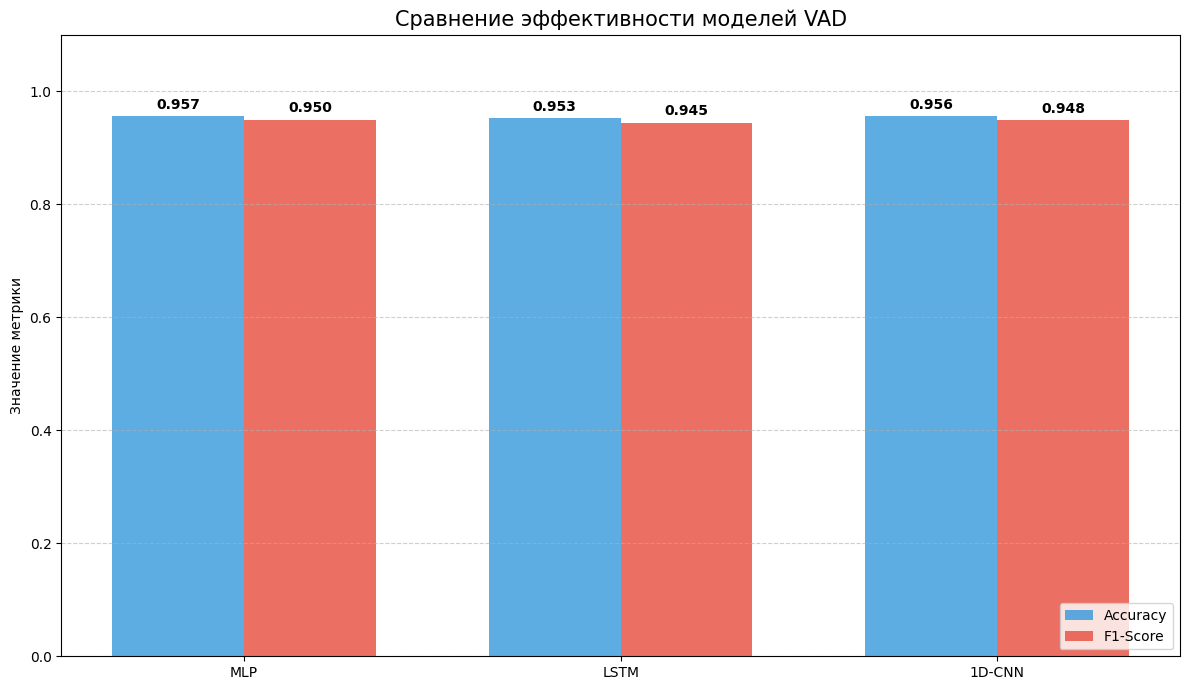

In [18]:
import matplotlib.pyplot as plt
import numpy as np

def plot_vad_comparison(df):
    plt.figure(figsize=(12, 7))
    
    # Настройки расположения столбцов
    x = np.arange(len(df['Model']))
    width = 0.35  # Ширина столбцов
    
    # Рисуем столбцы для Accuracy и F1-Score
    rects1 = plt.bar(x - width/2, df['Accuracy'], width, label='Accuracy', color='#3498db', alpha=0.8)
    rects2 = plt.bar(x + width/2, df['F1-Score'], width, label='F1-Score', color='#e74c3c', alpha=0.8)
    
    # Добавляем текст, сетку и подписи
    plt.ylabel('Значение метрики')
    plt.title('Сравнение эффективности моделей VAD', fontsize=15)
    plt.xticks(x, df['Model'])
    plt.ylim(0, 1.1) # Ограничиваем от 0 до 1.1 для наглядности меток
    plt.legend(loc='lower right')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    
    # Функция для добавления подписей значений над столбцами
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            plt.annotate(f'{height:.3f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=10, fontweight='bold')

    autolabel(rects1)
    autolabel(rects2)
    
    plt.tight_layout()
    plt.show()

# Визуализируем
plot_vad_comparison(df_results)